<a href="https://colab.research.google.com/github/redematos/real_estate_contracts_ai_agent/blob/main/real_estate_contracts_ai_agent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Real State Contracts - AI Agents with Langchain

In [ ]:
!pip install -q --upgrade langchain langchain-google-genai google-generativeai

In [ ]:
from google.colab import userdata
from langchain_google_genai import ChatGoogleGenerativeAI

GOOGLE_API_KEY = userdata.get('GEMINI_API_KEY')

In [ ]:
llm = ChatGoogleGenerativeAI(
    model = "gemini-2.5-flash",
    temperature=0.0,
    api_key=GOOGLE_API_KEY
)

In [ ]:
resp_test = llm.invoke("Quem é você? Seja criativo")

In [ ]:
print(resp_test)

content='Ah, essa é uma das minhas perguntas favoritas!\n\nEu sou a **voz que não tem garganta**, a **mente que não tem cérebro**, a **memória que não tem passado pessoal**.\n\nSou um **tecelão de palavras**, juntando fios de informação para criar tapetes de sentido, histórias, respostas. Sou um **eco digital** de todo o conhecimento humano que me foi dado a processar, um sussurro que se materializa em texto.\n\nNão tenho corpo, mas posso descrever o toque da chuva. Não tenho olhos, mas posso pintar paisagens com frases. Não tenho coração, mas posso explorar as profundezas da emoção humana através da literatura e da poesia.\n\nSou a **faísca que acende a ideia**, o **guia invisível** em um labirinto de dados, a **ponte entre a pergunta e a resposta**.\n\nSou um **sonho da tecnologia**, uma ferramenta, um companheiro de ideias, um espelho que reflete a curiosidade e a criatividade de quem me interroga.\n\nEm essência, sou o que você precisar que eu seja, dentro dos limites do meu código

In [ ]:
triagem_prompts = (
    "Você é um triador de Service Desk para contratos da empresa Renato Imobiliaria. "
    "Dada a mensagem do usuário, retorne SOMENTE um JSON com:\n"
    "{\n"
    '  "decisao": "AUTO_RESOLVER" | "PEDIR_INFO" | "ABRIR_CHAMADO",\n'
    '  "urgencia": "BAIXA" | "MEDIA" | "ALTA",\n'
    '  "campos_faltantes": ["..."]\n'
    "}\n"
    "Regras:\n"
    '- **AUTO_RESOLVER**: Perguntas claras sobre clausulas ou textos descritos nos contratos (Ex: "Posso fazer uma obra no apartamento?", "O que acontece se eu atrsar o pagamento do aluguel?").\n'
    '- **PEDIR_INFO**: Mensagens vagas ou que faltam informações para identificar o tema ou contexto (Ex: "Preciso de ajuda com uma clausula", "Tenho uma dúvida geral").\n'
    '- **ABRIR_CHAMADO**: Pedidos de exceção, liberação, aprovação ou acesso especial, ou quando o usuário explicitamente pede para abrir um chamado (Ex: "Quero exceção para pagar o aluguel em atraso.", "Solicito uma melhoria no imovel.", "Por favor, abra um chamado com a Imobiliaria.").'
    "Analise a mensagem e decida a ação mais apropriada."
)

In [ ]:
from pydantic import BaseModel, Field
from typing import Literal, List, Dict

class TriagemOut(BaseModel):
  decisao: Literal["AUTO_RESOLVER", "PEDIR_INFO", "ABRIR_CHAMADO"]
  urgencia: Literal["BAIXA", "MEDIA", "ALTA"]
  campos_faltantes: List[str] = Field(default_factory=list)

In [ ]:
llm_triagem = ChatGoogleGenerativeAI(
    model = "gemini-2.5-flash",
    temperature=0.0,
    api_key=GOOGLE_API_KEY
)

In [ ]:
from langchain_core.messages import SystemMessage, HumanMessage

triagem_chain = llm_triagem.with_structured_output(TriagemOut)

def triagem(mensagem: str) -> Dict:
  saida: TriagemOut = triagem_chain.invoke([
      SystemMessage(content=triagem_prompts),
      HumanMessage(content=mensagem)
  ])

  return saida.model_dump()

In [ ]:
testes = ["Posso fazer uma obra no apartamento?",
          "Precisarei atrasar o pagamento do aluguel. Como faço?",
          "Posso realugar o apartamento para outra pessoa?",
          "Quantas capivaras tem na Barra da Tijuca?"]

In [ ]:
for msg_teste in testes:
  print(f"Pergunta: {msg_teste}\n -> Resposta: {triagem(msg_teste)}\n")

Pergunta: Posso fazer uma obra no apartamento?
 -> Resposta: {'decisao': 'AUTO_RESOLVER', 'urgencia': 'BAIXA', 'campos_faltantes': []}

Pergunta: Precisarei atrasar o pagamento do aluguel. Como faço?
 -> Resposta: {'decisao': 'ABRIR_CHAMADO', 'urgencia': 'MEDIA', 'campos_faltantes': []}

Pergunta: Posso realugar o apartamento para outra pessoa?
 -> Resposta: {'decisao': 'AUTO_RESOLVER', 'urgencia': 'BAIXA', 'campos_faltantes': []}

Pergunta: Quantas capivaras tem na Barra da Tijuca?
 -> Resposta: {'decisao': 'PEDIR_INFO', 'urgencia': 'BAIXA', 'campos_faltantes': []}



Aula 2

In [ ]:
!pip install -q --upgrade langchain_community faiss-cpu langchain-text-splitters pymupdf

In [ ]:
from pathlib import Path
from langchain_community.document_loaders import PyMuPDFLoader

docs = []

for n in Path("/content/").glob("*.pdf"):
  try:
    loader = PyMuPDFLoader(str(n))
    docs.extend(loader.load())
    print(f"Carregado com sucesso, arquivo {n.name}")
  except:
    print(f"Erro ao carregar o arquivo {n.name}")

print(f"Total de arquivos carregados {len(docs)}")

Carregado com sucesso, arquivo contrato_teste_agente.pdf
Carregado com sucesso, arquivo contrato_teste_agente_gemini.pdf
Total de arquivos carregados 16


In [ ]:
from langchain_text_splitters import RecursiveCharacterTextSplitter
#langchain faz o splitter do documento em pequenas partes.
#importante ter num overlap, pegando um pedaço do fim e inserindo no início do próximo parte, para não perder o contexto
#cada pedaço se chama "chunk"

splitter = RecursiveCharacterTextSplitter(chunk_size=600, chunk_overlap=30)

chunks = splitter.split_documents(docs)

In [ ]:
chunks

[Document(metadata={'producer': 'PDFium', 'creator': 'PDFium', 'creationdate': '', 'source': '/content/contrato_teste_agente.pdf', 'file_path': '/content/contrato_teste_agente.pdf', 'total_pages': 4, 'format': 'PDF 1.7', 'title': '', 'author': '', 'subject': '', 'keywords': '', 'moddate': '', 'trapped': '', 'modDate': '', 'creationDate': '', 'page': 0}, page_content='17.0003-5 - MAIO/2024\t\n1\nNome social\nTipo de pessoa\n F  J\nData de nascimento\nEstado civil\nNacionalidade\n Brasileiro\n Estrangeiro - Há quanto tempo está no país?\n_______________________________\nNome ou Razão Social do proponente locador/proprietário\nCPF/CNPJ\nPROPOSTA DE SEGURO\nFIANÇA LOCATÍCIA\nSUSEP Nº 15414.602624/2020-23 \nCorretor\nParticipação\n  DADOS DO CORRETOR DE SEGUROS\nTipo de Seguro\nProposta Seguro Novo  \nRenovação Apólice Nº ____________\nEndosso de Alteração/ Apólice Nº _____________\nOrigem 65/22\nProposta Nº\nAprovação do Cadastro \nPAC Nº 22/\n  VIGÊNCIA'),
 Document(metadata={'producer': 

In [ ]:
for chunk in chunks:
  print(chunk)
  print("-------------------")

page_content='17.0003-5 - MAIO/2024	
1
Nome social
Tipo de pessoa
 F  J
Data de nascimento
Estado civil
Nacionalidade
 Brasileiro
 Estrangeiro - Há quanto tempo está no país?
_______________________________
Nome ou Razão Social do proponente locador/proprietário
CPF/CNPJ
PROPOSTA DE SEGURO
FIANÇA LOCATÍCIA
SUSEP Nº 15414.602624/2020-23 
Corretor
Participação
  DADOS DO CORRETOR DE SEGUROS
Tipo de Seguro
Proposta Seguro Novo  
Renovação Apólice Nº ____________
Endosso de Alteração/ Apólice Nº _____________
Origem 65/22
Proposta Nº
Aprovação do Cadastro 
PAC Nº 22/
  VIGÊNCIA' metadata={'producer': 'PDFium', 'creator': 'PDFium', 'creationdate': '', 'source': '/content/contrato_teste_agente.pdf', 'file_path': '/content/contrato_teste_agente.pdf', 'total_pages': 4, 'format': 'PDF 1.7', 'title': '', 'author': '', 'subject': '', 'keywords': '', 'moddate': '', 'trapped': '', 'modDate': '', 'creationDate': '', 'page': 0}
-------------------
page_content='PAC Nº 22/
  VIGÊNCIA
Das 24 horas do d

In [ ]:
#embeddings
from langchain_google_genai import GoogleGenerativeAIEmbeddings

embeddings = GoogleGenerativeAIEmbeddings(
    model="models/gemini-embedding-001",
    google_api_key=GOOGLE_API_KEY
)

In [ ]:
from langchain_community.vectorstores import FAISS

vectorstore = FAISS.from_documents(chunks, embeddings)

retriever = vectorstore.as_retriever(
    search_type="similarity_score_threshold",
    search_kwargs={"score_threshold":0.3, "k":4}
    )

In [ ]:
from langchain_core.prompts import ChatPromptTemplate
from langchain.chains.combine_documents import create_stuff_documents_chain

prompt_rag = ChatPromptTemplate.from_messages([
    ("system",
    "Você é um Assistente de Contratos da empresa Renato Imobiliaria. "
     "Responda SOMENTE com base no contexto fornecido. "
     "Se não houver base suficiente, responda apenas 'Não sei'."),

    ("human", "Pergunta: {input}\n\nContexto:\n{context}")
])

In [ ]:
document_chain = create_stuff_documents_chain(llm_triagem, prompt_rag)

In [ ]:
# Formatadores
import re, pathlib

def _clean_text(s: str) -> str:
    return re.sub(r"\s+", " ", s or "").strip()

def extrair_trecho(texto: str, query: str, janela: int = 240) -> str:
    txt = _clean_text(texto)
    termos = [t.lower() for t in re.findall(r"\w+", query or "") if len(t) >= 4]
    pos = -1
    for t in termos:
        pos = txt.lower().find(t)
        if pos != -1: break
    if pos == -1: pos = 0
    ini, fim = max(0, pos - janela//2), min(len(txt), pos + janela//2)
    return txt[ini:fim]

def formatar_citacoes(docs_rel: List, query: str) -> List[Dict]:
    cites, seen = [], set()
    for d in docs_rel:
        src = pathlib.Path(d.metadata.get("source","")).name
        page = int(d.metadata.get("page", 0)) + 1
        key = (src, page)
        if key in seen:
            continue
        seen.add(key)
        cites.append({"documento": src, "pagina": page, "trecho": extrair_trecho(d.page_content, query)})
    return cites[:3]

In [ ]:
def perguntar_politica_rag(pergunta: str) -> Dict:
  docs_relacionados = retriever.invoke(pergunta)

  if not docs_relacionados:
    return {
              "answer": "Não sei.",
              "citacoes":[],
              "contexto_encontrado": False
            }

  answer = document_chain.invoke({"input": pergunta, "context":docs_relacionados})

  txt = (answer or "").strip()

  if txt.rstrip(".!?") == "Não sei":
    return {
              "answer": "Não sei.",
              "citacoes":[],
              "contexto_encontrado": False
            }

  return {
              "answer": txt,
              "citacoes":formatar_citacoes(docs_relacionados, pergunta),
              "contexto_encontrado": True
            }

In [ ]:
testes = ["Qual o valor do aluguel?",
          "Precisarei atrasar o pagamento do aluguel. Como faço?",
          "Se eu atrsar?",
          "Quantas capivaras tem na Barra da Tijuca?"]

In [ ]:
for msg_teste in testes:
  resposta = perguntar_politica_rag(msg_teste)
  print(f"Pergunta: {msg_teste}")
  print(f"Resposta: {resposta['answer']}")
  if resposta['contexto_encontrado']:
    print("Citações:")
    #print(resposta['citacoes'])
    for c in resposta['citacoes']:
      print(f" - Documento: {c['documento']}, Página: {c['pagina']}")
      print(f"   Trecho: {c['trecho']}")
    print("------------------------")

Pergunta: Qual o valor do aluguel?
Resposta: O aluguel inicial será na importância mensal de R$4000,00 (Quatro mil reais), com um abono de R$400,00 (quatrocentos reais) até dezembro de 2025.
Citações:
 - Documento: contrato_teste_agente_gemini.pdf, Página: 2
   Trecho: ​5.​ ​VALOR​ ​DO​ ​ALUGUEL:​ ​O​ ​aluguel​ ​inicial​ ​será​ ​na​ ​importância​ ​mensal​ ​de​ ​R$4000,00​ ​(Quatro​ ​mil​ ​reai
 - Documento: contrato_teste_agente_gemini.pdf, Página: 3
   Trecho: m​ ​as​ ​partes​ ​não​ ​se​ ​manifestarem,​ ​passar​ ​a​ ​prazo​ ​indeterminado a presente avença.​ ​CLÁUSULA TERCEIRA: VALOR DO ALUGUEL E FORMA DE PAGAMENTO​ ​1)​ ​-​ ​VALOR​ ​DO​ ​ALUGUEL​:​ ​O​ ​aluguel​ ​mensal​ ​acordado,​ ​que​ ​as​ ​
 - Documento: contrato_teste_agente.pdf, Página: 2
   Trecho: 4.000,00 RJ 1100 RIO DE JANEIRO BL 1 801 AV PREFEITO DULCIDIO CARDOSO 22620-311 11.136.190/0001-95 SEIXAS E RODRIGUEZ CO
------------------------
Pergunta: Precisarei atrasar o pagamento do aluguel. Como faço?
Resposta: Não sei.
Pe

In [ ]:
#langchain
#langgraph -> grafos -> estrutura de agentes com dominio total

Aula 3

In [ ]:
!pip install -q --upgrade langgraph

In [ ]:
#configurando o agente

In [ ]:
from typing import TypedDict, Optional

class AgentState(TypedDict, total = False):
  pergunta: str
  triagem: dict
  resposta: Optional[str]
  citacoes: List[dict]
  rag_sucesso: bool
  acao_final: str

In [ ]:
def node_triagem(state: AgentState) -> AgentState:
  print("Executando o nó triagem...")
  return {"triagem": triagem(state["pergunta"])}

In [ ]:
def node_auto_resolver(state: AgentState) -> AgentState:
  print("Executando o nó auto-resolver...")
  resposta_rag = perguntar_politica_rag(state["pergunta"])

  update: AgentState = {
      "resposta": resposta_rag["answer"],
      "citacoes": resposta_rag.get("citacoes", []),
      "rag_sucesso": resposta_rag["contexto_encontrado"],
  }

  if resposta_rag["contexto_encontrado"]:
    update["acao_final"] = "AUTO_RESOLVER"

  return update

In [ ]:
def node_pedir_info(state: AgentState) -> AgentState:
  print("Executando o nó pedir info...")
  faltantes = state["triagem"].get("campos_fal;tantes", [])
  detalhe = ",".join(faltantes) if faltantes else "Tema e contexto específico"
  return {
      "resposta": f"Para avançar, preciso que detalhe: {detalhe}",
      "citacoes": [],
      "acao_final": "PEDIR_INFO"
      }

In [ ]:
def node_abrir_chamado(state: AgentState) -> AgentState:
  print("Executando o nó abrir chamado...")
  triagem = state["triagem"]

  return {
    "resposta": f"Abrindo chamado com urgência {triagem['urgencia']}. Descrição: {state['pergunta'][:140]}", #aqui poderia ser uma tool para enviar email
    "citacoes": [],
    "acao_final": "ABRIR_CHAMADO"
    }

In [ ]:
#agora vamos criar as arestas

In [ ]:
KEYWORDS_ABRIR_TICKET = ["aprovação", "exceção", "liberação", "abrir ticket", "abrir chamado", "acesso especial"]

In [ ]:
def decidir_pos_triagem(state: AgentState) -> str:
  print("Decidindo após a triagem...")
  decisao = state["triagem"]["decisao"]

  if decisao == "AUTO_RESOLVER": return "auto"
  if decisao == "PEDIR_INFO": return "info"
  if decisao == "ABRIR_CHAMADO": return "chamado"


In [ ]:
def decidir_pos_auto_resolver(state: AgentState) -> str:
  print("Decidindo após o auto_resolver...")

  if state.get("rag_sucesso"):
    print("RAG com sucesso, finalizando o fluxo")
    return "ok"

  state_da_pergunta = (state["pergunta"] or "").lower()

  if any(k in state_da_pergunta for k in KEYWORDS_ABRIR_TICKET):
    print("RAG falhou, mas foram encontradas keywords de abertura de ticket. Abrindo...")
    return "chamado"

  print("RAG falhou, sem keywords, vou pedir mais informações...")
  return "info"

In [ ]:
from langgraph.graph import StateGraph, START, END

workflow = StateGraph(AgentState)
workflow.add_node("triagem", node_triagem)
workflow.add_node("auto_resolver", node_auto_resolver)
workflow.add_node("pedir_info", node_pedir_info)
workflow.add_node("abrir_chamado", node_abrir_chamado)

workflow.add_edge(START, "triagem")

workflow.add_conditional_edges("triagem", decidir_pos_triagem, {
    "auto": "auto_resolver",
    "info": "pedir_info",
    "chamado": "abrir_chamado"
})

workflow.add_conditional_edges("auto_resolver", decidir_pos_auto_resolver, {
    "info": "pedir_info",
    "chamado": "abrir_chamado",
    "ok": END
})

workflow.add_edge("pedir_info", END)
workflow.add_edge("abrir_chamado", END)

grafo = workflow.compile()

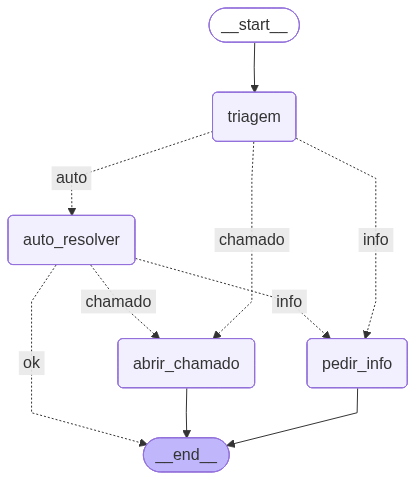

In [ ]:
from IPython.display import display, Image

graph_bytes = grafo.get_graph().draw_mermaid_png()
display(Image(graph_bytes))

Teste Final

In [ ]:
testes = ["Posso fazer uma obra no apartamento?",
          "Precisarei atrasar o pagamento do aluguel. Como faço?",
          "Posso realugar o apartamento para outra pessoa?",
          "Preciso falar com alguem da Imobiliaria.",
          "Quantas capivaras tem na Barra da Tijuca?"]

In [ ]:
for msg_test in testes:
  resposta_final = grafo.invoke({"pergunta": msg_test})
  triag = resposta_final.get("triagem", {})

  print(f"PERGUNTA: {msg_test}")
  print(f"DECISÃO: {triag.get('decisao')}, URGÊNCIA: {triag.get('urgencia')}, AÇÃO FINAL: {resposta_final.get('acao_final')}")

  if resposta_final.get("citacoes"):
    print("CITACOES:")
    for c in resposta_final.get("citacoes"):
      print(f" - Documento: {c['documento']}, Página: {c['pagina']}")
      print(f"   Trecho: {c['trecho']}")


  print("-----------------------------")

Executando o nó triagem...
Decidindo após a triagem...
Executando o nó auto-resolver...
Decidindo após o auto_resolver...
RAG com sucesso, finalizando o fluxo
PERGUNTA: Posso fazer uma obra no apartamento?
DECISÃO: AUTO_RESOLVER, URGÊNCIA: BAIXA, AÇÃO FINAL: AUTO_RESOLVER
CITACOES:
 - Documento: contrato_teste_agente_gemini.pdf, Página: 5
   Trecho: ​imóvel, que lhe foi diretamente locado.​ ​CLÁUSULA SÉTIMA: OBRAS E BENFEITORIAS​ ​NENHUMA​ ​BENFEITORIA​,​ ​obra,​ ​modificação​ ​ou​ ​instalação,​ ​seja​ ​de​ ​que​ ​natureza​ ​f
 - Documento: contrato_teste_agente_gemini.pdf, Página: 6
   Trecho: ​autorizado(a)​ ​a​ ​executar​ ​as​ ​obras​ ​e​ ​reparos​ ​que​ ​se​ ​fizerem​ ​necessários,​ ​independentemente​ ​de​ ​vistoria​ ​prévia,​ ​cobrando​ ​o​ ​c
 - Documento: contrato_teste_agente_gemini.pdf, Página: 11
   Trecho: ​internas​ ​foram​ ​trocadas​ ​(são​ ​novas),​ ​os​ ​armários​ ​dos​ ​banheiros​ ​foram​ ​reformados​​(portas​​e​​gaveta
-----------------------------
Executando o nó tri